In [1]:
# Init the environment
import sys
import schemdraw
import schemdraw.elements as schemelem
import matplotlib
import matplotlib.pyplot as plt
import numpy
sys.path.insert(0, "../../..")

from init_physics_env import *

## LB. S. 428
### Nr. 4.
$$
\begin{align*}
\lambda &= 400 \text{ nm} \\
E_\text{kin} &= 1,8 \text{ eV}
\end{align*}
$$

#### a.
$$
\begin{align*}
E_\text{kin} &= hf - W_A \\
E_\text{kin}\left(\frac{c}{400 \text{ nm}}\right) &= 1,8 \text{ eV} \\
\rightarrow 1,8 \text{ eV} &= \frac{hc}{400 \text{ nm}} - W_A \\
\rightarrow W_A &= \frac{hc}{400 \text{ nm}} - 1,8 \text{ eV} \\
E_\text{kin}(f_G) &= 0 \\
\rightarrow f_G &= \frac{W_A}{h} \\
&= \frac{c}{400 \text{ nm}} - \frac{1,8 \text{ eV}}{h}
\end{align*}
$$

In [4]:
lamb = Rational(400, 1000000000)
E_kin = Rational(18,10) * Eval.elementary_charge

(
    Eq(Symbol("W_A"), (Eval.planck_constant*Eval.light_speed / lamb - E_kin).evalf() * Symbol("\\text{ J}")),
    Eq(Symbol("W_A"), ((Eval.planck_constant*Eval.light_speed / lamb - E_kin)/Eval.elementary_charge).evalf() * Symbol("\\text{ eV}")),
    Eq(Symbol("f_G"), (Eval.light_speed/lamb - E_kin/Eval.planck_constant).evalf() * Symbol("\\text{ Hz}")),
    Eq(Symbol("f_G"), ((Eval.light_speed/lamb - E_kin/Eval.planck_constant) / Integer(1000000000000)).evalf() * Symbol("\\text{ THz}")),
)

### Nr. 6.
#### a.

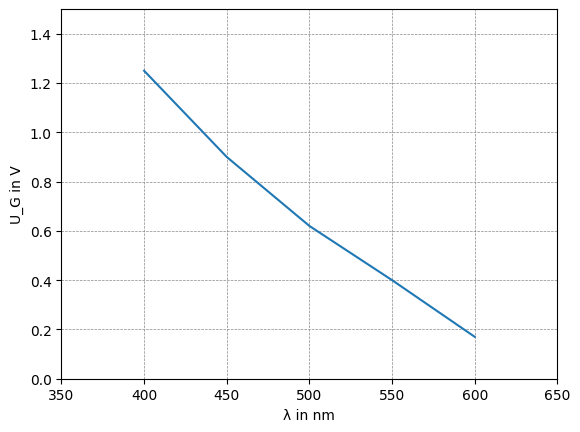

In [6]:
plt.plot([400, 450, 500, 550, 600], [1.25, 0.9, 0.62, 0.4, 0.17])
plt.ylabel("U_G in V")
plt.xlabel("λ in nm")
plt.axis((350, 650, 0, 1.5))
plt.grid(true, "major", "both", color='#888888', linestyle='--', linewidth=0.5)
plt.show()

Das Diagramm zeigt die Gegenspannung zum annullieren des Fotostroms, in Abhängigkeit von der Wellenlänge des auf die Vakuumfotozelle gestrahlten Lichts. Es lässt sich erkennen, dass die Gegenspannung mit höherer Wellenlänge abnimmt.

#### b.
$$
\begin{align*}
E(f) &= hf - W_A \\
E &= e\cdot U_G \\
f &= \frac{c}{\lambda} \\
\end{align*}
$$

Über lineare Regression lassen sich nun die Werte für $h$ und $W_A$ bestimmen:

$$
\begin{align*}
h &= 6,846 \cdot 10^{-34} \text{ Js} \\
W_A &= 3,120 \cdot 10^{-19} \text{ J}
\end{align*}
$$

Zuletzt lässt sich noch über Umformen der Gleichung $f_G$ bestimmen:
$$
\begin{align*}
E(f_G) &= hf_G - W_A \\
&= 0 \\
\rightarrow f_G &= \frac{W_A}{h}
\end{align*}
$$

In [9]:
Eq(Symbol("f_G"), (Rational(3119767,1000000)*Integer(10)**-19/(Rational(6846241,1000000)*Integer(10)**-34) / 1000000000000).evalf() * Symbol("\\text{ THz}"))

#### c.
$$
\begin{align*}
E_\text{kin}(\lambda) &= \frac{hc}{\lambda} - W_A \\
&= \frac12mv^2 \\
\rightarrow v(\lambda) &= \sqrt2\sqrt{\frac{hc}{\lambda m} - \frac{W_A}{m} }
\end{align*}
$$

In [10]:
W_A = Rational(3120,1000) * Integer(10)**-19

[(sqrt(2)*sqrt(Eval.planck_constant * Eval.light_speed/(lamb * Eval.mass.electron) - W_A / Eval.mass.electron)).evalf() for lamb in [400, 450, 500, 550, 600]]